In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

In [3]:
con = duckdb.connect()

In [4]:
SALES_PATH = "../data/processed/*.parquet"

Business Question

How do we predict the daily demand for each item store combination for next 28 days accurately enough?
- so that we can support the retail inventory and replinshments of the required items in the stores.
- we can avoid stockouts of the items and boost the sales

## Stage 1: Understanding Target Variable 
- Grain of the data
- Sales distribution
- How intermittent the sales is (zero sales vs positive sales)
- Does the intermittent sale prevalent across all the stores for all the products? or only happening for certain combination of items and stores?

In [5]:
# grain of the data - itemxstorexdate

query = f"""

        select s.store_id,s.item_id,s.date,count(*) as grain_count
        from read_parquet('{SALES_PATH}') as s
        group by s.store_id,s.item_id,s.date
        having count(*)>1
        order by s.store_id,s.item_id,s.date
    """

result = con.execute(query).df()
result

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,store_id,item_id,date,grain_count


In [6]:
# grain of the data - itemxstorexdate

query = f"""

        select count(*) as total_observations,min(sales),max(sales),avg(sales),median(sales),stddev(sales)
        from read_parquet('{SALES_PATH}')
    """

result = con.execute(query).df()
result

,total_observations,min(sales),max(sales),avg(sales),median(sales),stddev(sales)
0,58327370,0,763,1.126322,0.0,3.873108


In [7]:
# sales distribution

query = f"""

        select sales, 
        count(*) as sales_dist,
        round(count(*)*100/sum(count(*)) over(),2) as pct
        from read_parquet('{SALES_PATH}')
        where sales <= 1000
        group by sales
        order by sales
    """

result = con.execute(query).df()
result

,sales,sales_dist,pct
0,0,39777094,68.20
1,1,7753194,13.29
2,2,3894493,6.68
3,3,2098127,3.60
4,4,1279524,2.19
...,...,...,...
414,634,1,0.00
415,648,1,0.00
416,693,1,0.00
417,709,2,0.00


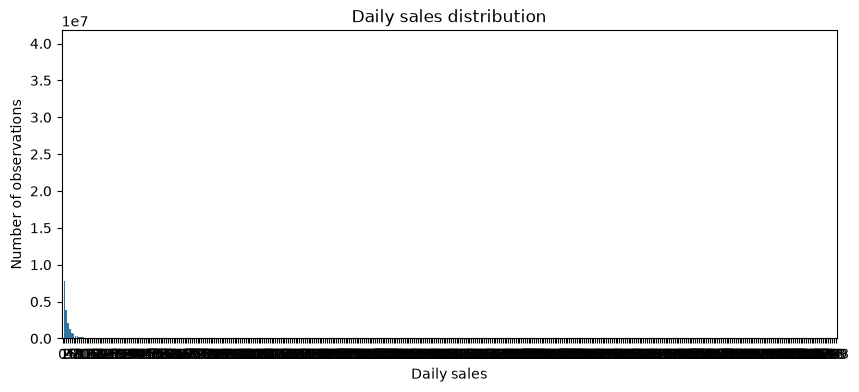

In [8]:
plt.figure(figsize=(10,4))
sns.barplot(data=result, x="sales", y="sales_dist")

plt.title("Daily sales distribution")
plt.xlabel("Daily sales")
plt.ylabel("Number of observations")
plt.show()

In [9]:
# grain of the data - itemxstorexdate

query = f"""

        select 
            case
                when sales=0 then '0'
                when sales between 1 and 5 then '1-5'
                when sales between 6 and 10 then '6-10'
                when sales between 11 and 20 then '11-20'
                when sales between 21 and 50 then '21-50'
                when sales between 51 and 100 then '51-100'                    
                else '100+'
            end as "sales_bucket",
            count(*) as sales_dist
        from read_parquet('{SALES_PATH}')
        group by sales_bucket
                order by 
            case sales_bucket
                when '0' then 1
                when '1-5' then 2
                when '6-10' then 3
                when '11-20' then 4
                when '21-50' then 5
                when '51-100' then 6
                else 7
            end;

    """

result = con.execute(query).df()
result

,sales_bucket,sales_dist
0,0,39777094
1,1-5,15837991
2,6-10,1660736
3,11-20,717960
4,21-50,284985
5,51-100,41548
6,100+,7056


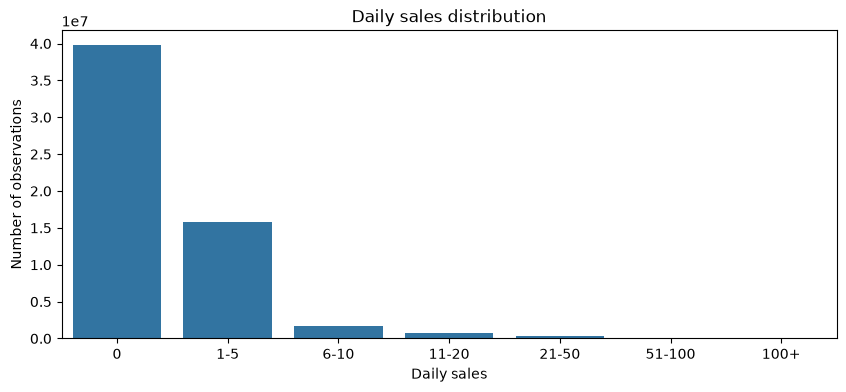

In [10]:
plt.figure(figsize=(10,4))
sns.barplot(data=result, x="sales_bucket", y="sales_dist")

plt.title("Daily sales distribution")
plt.xlabel("Daily sales")
plt.ylabel("Number of observations")
plt.show()

In [11]:
# sales distribution, checking upper tail where the highest unit are sold but their frequency are very less or negligible

query = f"""

        select state_id,store_id,item_id,cat_id,date,weekday,sell_price,sales,event_type_1,event_name_1,snap
        from read_parquet('{SALES_PATH}')
        order by sales desc
        limit 30
    """

result = con.execute(query).df()
result

,state_id,store_id,item_id,cat_id,date,weekday,sell_price,sales,event_type_1,event_name_1,snap
0,CA,CA_3,FOODS_3_090,FOODS,2013-09-14,Saturday,1.00,763,No Event,No Event,0.0
1,CA,CA_3,FOODS_3_090,FOODS,2013-08-23,Friday,1.00,709,No Event,No Event,0.0
2,CA,CA_3,FOODS_3_090,FOODS,2013-09-13,Friday,1.00,709,No Event,No Event,0.0
3,CA,CA_3,FOODS_3_090,FOODS,2011-12-31,Saturday,1.28,693,No Event,No Event,0.0
4,CA,CA_1,FOODS_3_785,FOODS,2012-06-22,Friday,3.34,648,No Event,No Event,0.0
5,TX,TX_1,FOODS_2_285,FOODS,2011-05-06,Friday,2.36,634,No Event,No Event,1.0
6,CA,CA_3,FOODS_3_090,FOODS,2011-12-23,Friday,1.28,633,No Event,No Event,0.0
7,TX,TX_2,HOUSEHOLD_1_474,HOUSEHOLD,2013-07-24,Wednesday,0.97,626,No Event,No Event,0.0
8,CA,CA_3,FOODS_3_090,FOODS,2013-09-11,Wednesday,1.00,620,No Event,No Event,0.0
9,CA,CA_3,FOODS_3_090,FOODS,2011-12-24,Saturday,1.28,619,No Event,No Event,0.0


In [12]:
# sales distribution, checking upper tail where the highest unit are sold but their frequency are very less or negligible

query = f"""
        select store_id,cat_id,weekday,event,snap,price, count(*) as sales_count
        from
        (select store_id,cat_id,weekday,
            case when sell_price between 0.0 and 5.0 then 'low_price'
            else 'high_price'
            end as 'price',
            case when event_type_1='No Event' then 'No Event'
            else 'Event'
            end as 'event',
            snap
        from read_parquet('{SALES_PATH}')
        where sales>400 and sales <800
        )
        group by store_id,cat_id,weekday,event,snap,price
        order by count(*) desc
        
    """

result = con.execute(query).df()
result

,store_id,cat_id,weekday,event,snap,price,sales_count
0,CA_3,FOODS,Saturday,No Event,0.0,low_price,10
1,CA_3,FOODS,Friday,No Event,0.0,low_price,5
2,CA_3,FOODS,Saturday,No Event,1.0,low_price,4
3,CA_3,FOODS,Sunday,No Event,0.0,low_price,3
4,CA_3,FOODS,Monday,No Event,0.0,low_price,3
5,CA_3,FOODS,Thursday,No Event,0.0,low_price,2
6,CA_3,FOODS,Wednesday,No Event,0.0,low_price,2
7,TX_2,HOUSEHOLD,Wednesday,No Event,0.0,low_price,2
8,CA_3,FOODS,Tuesday,No Event,1.0,low_price,1
9,CA_3,FOODS,Tuesday,No Event,0.0,low_price,1


In [16]:
# How 68.2% of zero sales distributed? zero sales before and after product launch

query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select 
        count(*) as total_observations,
        count(*) filter(where sales=0) as zero_sales,
        count(*) filter(where sales>0) as positive_sales,
        count(*) filter(where sales=0 and s.date<l.launch_date) as zero_sales_before_launch,
        count(*) filter(where sales=0 and s.date>=l.launch_date) as zero_sales_after_launch,
        round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct,
        round(count(*) filter(where sales>0)/count(*)*100,2) as positive_sales_pct,
        round(count(*) filter(where sales=0 and s.date<l.launch_date)/count(*) filter(sales=0)*100.0,2) as pct_zero_sales_before_launch,
        round(count(*) filter(where sales=0 and s.date>=l.launch_date)/count(*) filter(sales=0)*100.0,2) as pct_zero_sales_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        
    """

result = con.execute(query).df()
result

,total_observations,zero_sales,positive_sales,zero_sales_before_launch,zero_sales_after_launch,zero_sales_pct,positive_sales_pct,pct_zero_sales_before_launch,pct_zero_sales_after_launch
0,58327370,39777094,18550276,12299413,27477681,68.2,31.8,30.92,69.08


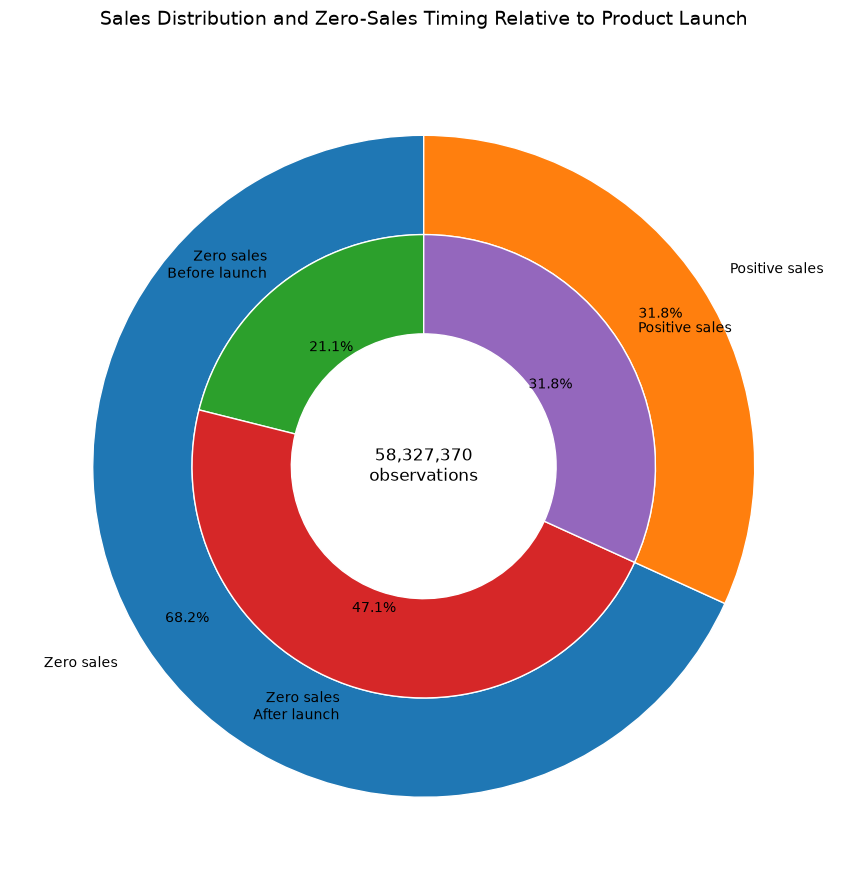

In [17]:
import matplotlib.pyplot as plt

# Values from query
zero_sales = result.loc[0, "zero_sales"]
positive_sales = result.loc[0, "positive_sales"]

zero_before = result.loc[0, "zero_sales_before_launch"]
zero_after = result.loc[0, "zero_sales_after_launch"]

# Total observations
total = result.loc[0, "total_observations"]


outer_values = [zero_sales, positive_sales]
outer_labels = ["Zero sales", "Positive sales"]


inner_values = [zero_before, zero_after, positive_sales]
inner_labels = [
    "Zero sales\nBefore launch",
    "Zero sales\nAfter launch",
    "Positive sales"
]

fig, ax = plt.subplots(figsize=(9, 9))

# Outer ring
ax.pie(
    outer_values,
    radius=1,
    labels=outer_labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.30, edgecolor="white"),
    pctdistance=0.85
)

# Inner ring
ax.pie(
    inner_values,
    radius=0.70,
    labels=inner_labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.30, edgecolor="white"),
    pctdistance=0.65
)

# Centre
ax.text(
    0, 0,
    f"{total:,}\nobservations",
    ha="center",
    va="center",
    fontsize=12
)

ax.set_title(
    "Sales Distribution and Zero-Sales Timing Relative to Product Launch",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

In [ ]:
# Lets explore the zero sale after the product launch whether is it consistent across all the items and stores or happening for only some of the item-store combination.


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.store_id,s.item_id,
            round(count(*) filter(where sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as pct_zero_sales_after_launch
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.store_id,s.item_id
        
    """

result = con.execute(query).df()
result["pct_zero_sales_after_launch"].describe()


count    30490.000000
mean        60.210202
std         23.363432
min          0.160000
25%         43.340000
50%         63.525000
75%         79.727500
max         99.310000
Name: pct_zero_sales_after_launch, dtype: float64

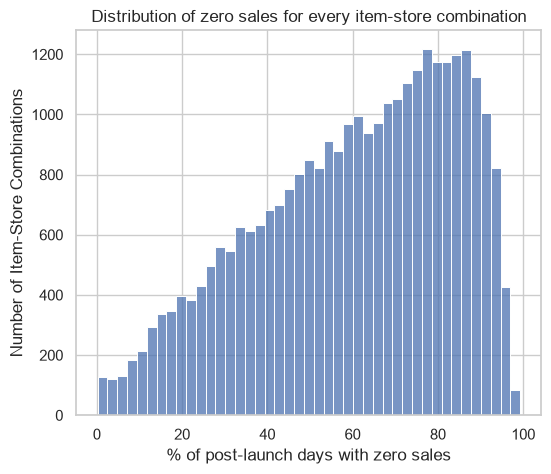

In [ ]:
plt.figure(figsize=(6,5))
sns.histplot(data=result, x="pct_zero_sales_after_launch")
plt.title("Distribution of zero sales for every item-store combination")
plt.xlabel("% of post-launch days with zero sales")
plt.ylabel("Number of Item-Store Combinations")

plt.show()

## Stage 2: Understanding how the target i.e sales behaves through time (how demand changes over the time)
- Overa all trend
- Seasonality (weekly, monthly etc)
- Dependency on previous day's sales
  

In [50]:
# How does sales behaves over the years? Does the sale increased or decreased? is there any trend?


query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.year,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.sales>0 and s.date>=l.launch_date) as total_sales
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.year
        order by s.year
        
    """

result = con.execute(query).df()
result


,year,zero_sales_pct,postive_sales_pct,total_sales
0,2011,55.37,44.63,3.885017
1,2012,57.93,42.07,3.967669
2,2013,60.11,39.89,3.713217
3,2014,62.17,37.83,3.363249
4,2015,60.78,39.22,3.190479
5,2016,57.92,42.08,3.219961


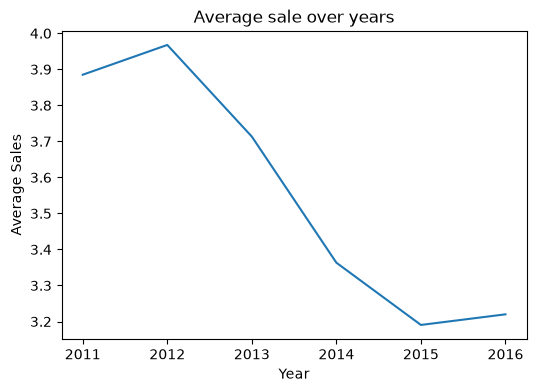

In [51]:
plt.figure(figsize=(6,4))
sns.lineplot(data=result,x="year",y="total_sales")
plt.title("Average sale over years")
plt.xlabel("Year")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.month,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.sales>0 and s.date>l.launch_date) as total_sales
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.month
        order by s.month
        
    """

result = con.execute(query).df()
result


,month,zero_sales_pct,postive_sales_pct,total_sales
0,1,60.54,39.46,1.109621
1,2,58.14,41.86,1.136262
2,3,58.72,41.28,1.126266
3,4,58.91,41.09,1.123604
4,5,59.89,40.11,1.066050
5,6,59.25,40.75,1.147964
6,7,59.77,40.23,1.151932
7,8,59.55,40.45,1.178965
8,9,59.47,40.53,1.163636
9,10,59.57,40.43,1.138520


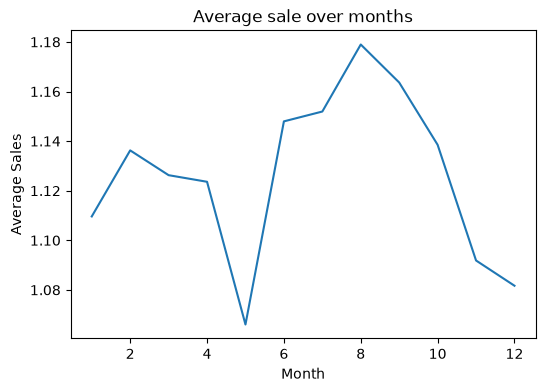

In [36]:
plt.figure(figsize=(6,4))
sns.lineplot(data=result,x="month",y="total_sales")
plt.title("Average sale over months")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

In [47]:
query = f"""
        with launch as
        (select store_id,item_id,min(wm_yr_wk) as launch_week,min(date) as launch_date
        from read_parquet('{SALES_PATH}')
        where sell_price is not null
        group by store_id,item_id)

        select s.year,s.month,
            round(count(*) filter(where s.sales=0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100.0,2) as zero_sales_pct,
            round(count(*) filter(where s.sales>0 and s.date>=l.launch_date)/count(*) filter(s.date>=l.launch_date)*100,2) as postive_sales_pct,
            avg(sales) filter(where s.sales>0 and s.date>l.launch_date) as total_sales
        from read_parquet('{SALES_PATH}') as s
        join launch as l
        on s.item_id=l.item_id
            and s.store_id=l.store_id
        group by s.year,s.month
        order by s.year,s.month
        
    """

result = con.execute(query).df()
result[result["year"]==2014]


,year,month,zero_sales_pct,postive_sales_pct,total_sales
36,2014,1,62.79,37.21,3.503001
37,2014,2,61.02,38.98,3.478849
38,2014,3,61.27,38.73,3.438588
39,2014,4,61.62,38.38,3.474111
40,2014,5,62.35,37.65,3.349196
41,2014,6,62.07,37.93,3.450610
42,2014,7,62.44,37.56,3.465008
43,2014,8,61.65,38.35,3.460895
44,2014,9,61.83,38.17,3.277986
45,2014,10,61.56,38.44,3.170953


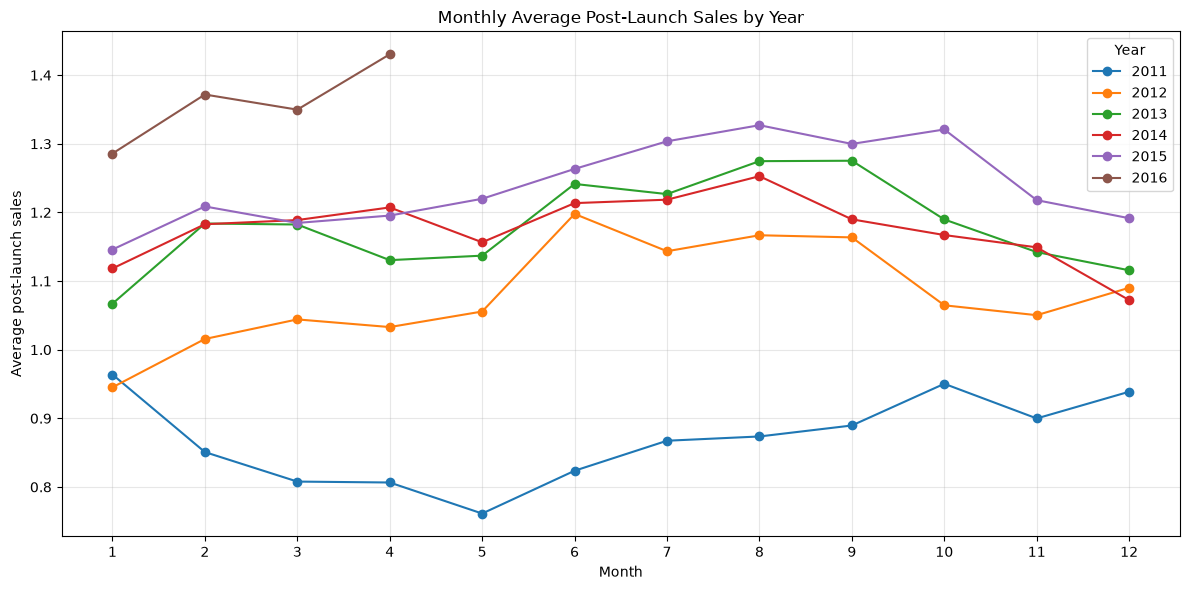

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for year, group in result.groupby("year"):
    plt.plot(
        group["month"],
        group["total_sales"],
        marker="o",
        label=str(year)
    )

plt.xlabel("Month")
plt.ylabel("Average post-launch sales")
plt.title("Monthly Average Post-Launch Sales by Year")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

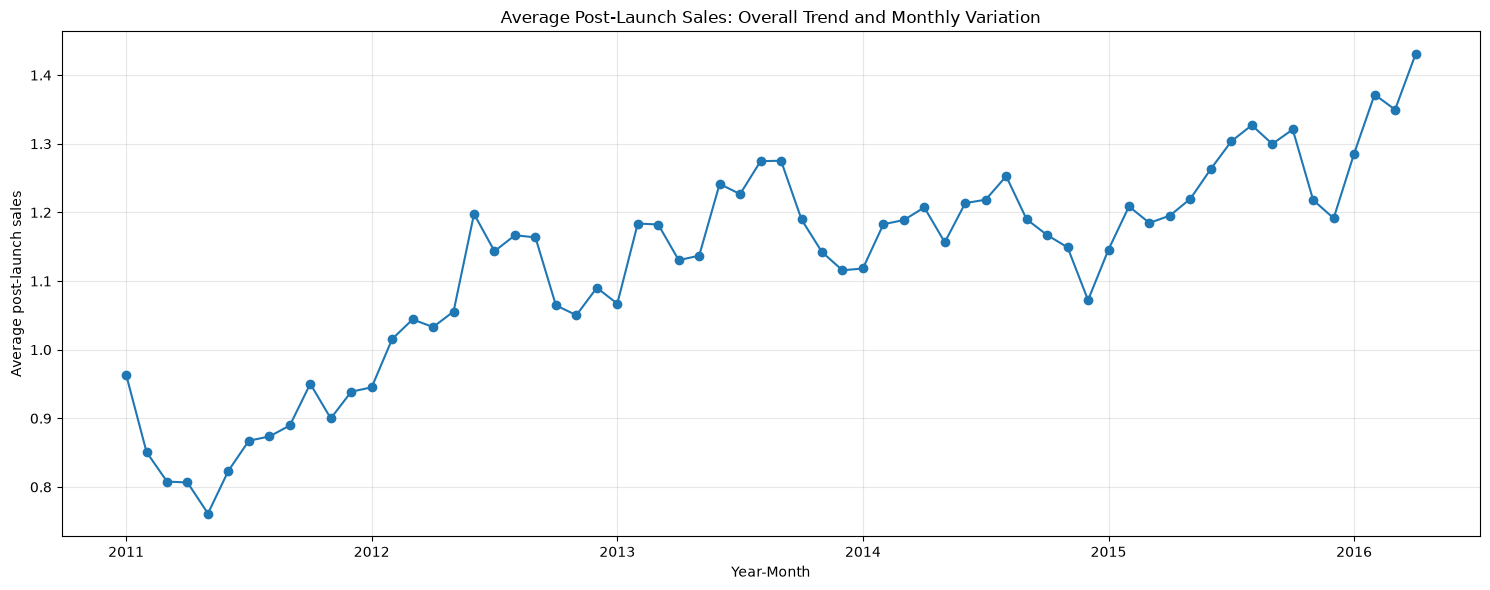

In [42]:
import matplotlib.pyplot as plt

result["year_month"] = (
    result["year"].astype(str) + "-" +
    result["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(15, 6))

plt.plot(
    result["year_month"],
    result["total_sales"],
    marker="o"
)

plt.xlabel("Year-Month")
plt.ylabel("Average post-launch sales")
plt.title("Average Post-Launch Sales: Overall Trend and Monthly Variation")

# Show only January as the year labels
jan_positions = result["month"] == 1

plt.xticks(
    result.index[jan_positions],
    result.loc[jan_positions, "year"],
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()